<center><h1>QBUS2820 Assignment 1 - Predicting Weekly Rent</h1></center>

**Student ID:** SID

1. Setup and data
2. Exploratory data analysis (EDA)
3. Modelling and model selection
4. Final model and predictions

`WeeklyRent_training.csv` and `WeeklyRent_test_noLabel.csv` must be in the same folder as this notebook.

## 1. Setup and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_context('notebook')
sns.set_style('ticks')

### Data

Load the training data (with `WeeklyRent`) and the test covariates, and store the response and predictor names.

In [2]:
train = pd.read_csv('WeeklyRent_training.csv')
test = pd.read_csv('WeeklyRent_test_noLabel.csv')

response = 'WeeklyRent'
predictors = [x for x in list(train.columns) if x != response] # building a list of predictors
continuous = ['DistanceCBD', 'FloorArea', 'PropertyAge']
binary = ['NearTrain', 'Furnished', 'HighDemandArea']

train.head()

,WeeklyRent,DistanceCBD,Bedrooms,FloorArea,PropertyAge,NearTrain,Furnished,HighDemandArea
0,774.30,1.57,1,49.1,24.9,0,1,0
1,980.10,12.33,2,96.1,14.0,1,0,1
2,686.14,23.70,2,82.0,1.1,0,1,0
3,968.39,6.85,1,59.9,12.3,1,1,1
4,849.06,19.88,3,93.5,8.0,1,0,0


## 2. Exploratory data analysis

### 2.1 Structure of the data

In [3]:
print('Training data: {} rows, {} columns'.format(train.shape[0], train.shape[1]))
print('Test data:     {} rows, {} columns'.format(test.shape[0], test.shape[1]))
train.dtypes

Training data: 5000 rows, 8 columns
Test data:     1000 rows, 7 columns


WeeklyRent        float64
DistanceCBD       float64
Bedrooms            int64
FloorArea         float64
PropertyAge       float64
NearTrain           int64
Furnished           int64
HighDemandArea      int64
dtype: object

All variables are numerical, and the three binary predictors are already 0/1 dummies, so no encoding is needed.

### 2.2 Missing values and duplicates

In [4]:
print('Missing values in training data: {}'.format(train.isna().sum().sum()))
print('Missing values in test data:     {}'.format(test.isna().sum().sum()))
print('Duplicated rows in training data: {}'.format(train.duplicated().sum()))

Missing values in training data: 0
Missing values in test data:     0
Duplicated rows in training data: 0


### 2.3 Summary statistics

In [5]:
train.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
WeeklyRent,5000.0,860.6811,215.4138,194.26,703.075,849.090,1003.3525,1741.4
DistanceCBD,5000.0,13.5099,9.5587,0.62,5.430,11.415,20.0900,40.0
Bedrooms,5000.0,2.3628,1.0902,1.00,2.000,2.000,3.0000,5.0
FloorArea,5000.0,87.8890,30.1933,35.00,65.000,85.700,108.2250,191.2
PropertyAge,5000.0,19.7222,14.1877,0.10,9.275,16.400,26.6000,100.0
NearTrain,5000.0,0.4620,0.4986,0.00,0.000,0.000,1.0000,1.0
Furnished,5000.0,0.2998,0.4582,0.00,0.000,0.000,1.0000,1.0
HighDemandArea,5000.0,0.4562,0.4981,0.00,0.000,0.000,1.0000,1.0


### 2.4 Training vs test covariates

Check that the test covariates look like the training covariates, so the model does not need to extrapolate.

In [6]:
comparison = pd.DataFrame({
    'Train mean': train[predictors].mean(),
    'Test mean': test[predictors].mean(),
    'Train std': train[predictors].std(),
    'Test std': test[predictors].std(),
    'Train min': train[predictors].min(),
    'Test min': test[predictors].min(),
    'Train max': train[predictors].max(),
    'Test max': test[predictors].max()
})
comparison.round(4)

,Train mean,Test mean,Train std,Test std,Train min,Test min,Train max,Test max
DistanceCBD,13.5099,13.6192,9.5587,9.5828,0.62,0.83,40.0,40.0
Bedrooms,2.3628,2.3430,1.0902,1.1003,1.00,1.00,5.0,5.0
FloorArea,87.8890,87.1842,30.1933,29.9266,35.00,35.00,191.2,186.8
PropertyAge,19.7222,19.4662,14.1877,13.3440,0.10,0.60,100.0,96.9
NearTrain,0.4620,0.4490,0.4986,0.4976,0.00,0.00,1.0,1.0
Furnished,0.2998,0.3140,0.4582,0.4643,0.00,0.00,1.0,1.0
HighDemandArea,0.4562,0.4530,0.4981,0.4980,0.00,0.00,1.0,1.0


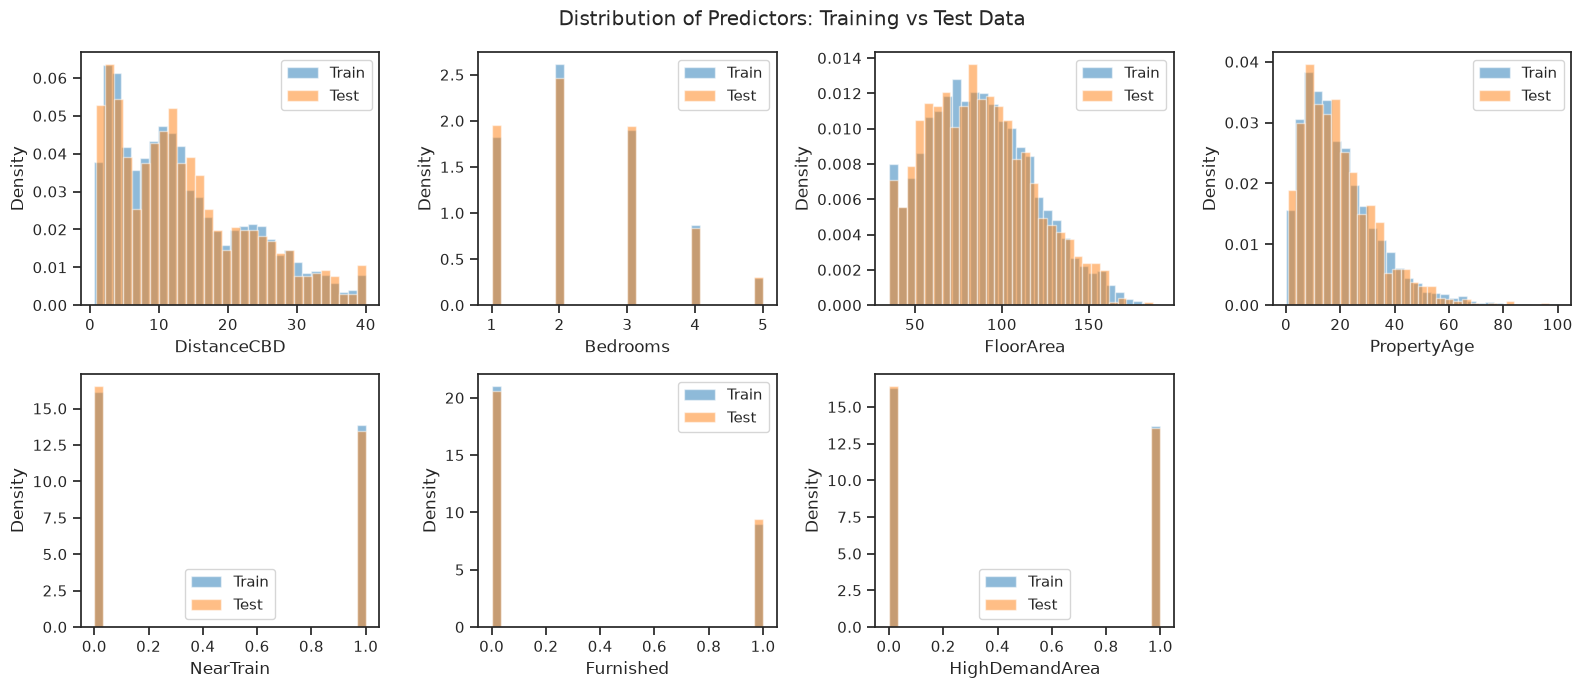

In [7]:
fig, ax = plt.subplots(2, 4, figsize=(16, 7))
ax = ax.flatten()

for i, var in enumerate(predictors):
    ax[i].hist(train[var], bins=30, density=True, alpha = 0.5, label = "Train")
    ax[i].hist(test[var], bins=30, density=True, alpha = 0.5, label = "Test")
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Density")
    ax[i].legend()

ax[7].axis('off') # only 7 predictors, so the last panel is empty
fig.suptitle("Distribution of Predictors: Training vs Test Data")
plt.tight_layout()
plt.show()

### 2.5 Distribution of the response

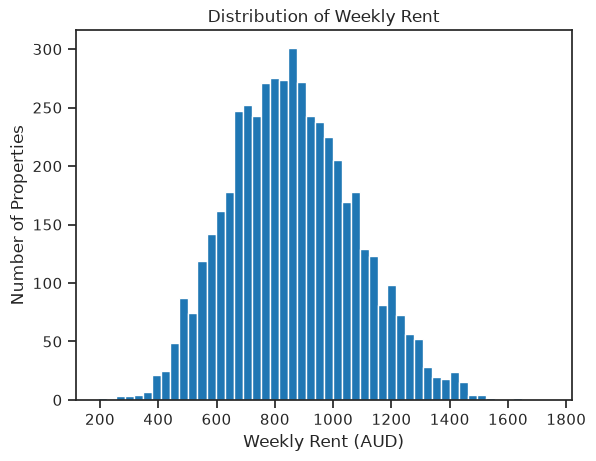

Mean: 860.6811, median: 849.0900, std: 215.4138, skewness: 0.2660


In [8]:
fig = plt.figure()

plt.hist(train[response], bins=50)
plt.xlabel("Weekly Rent (AUD)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Weekly Rent")

plt.show()

print('Mean: {0:.4f}, median: {1:.4f}, std: {2:.4f}, skewness: {3:.4f}'.format(
    train[response].mean(), train[response].median(), train[response].std(), train[response].skew()))

### 2.6 Weekly rent vs continuous predictors

A straight line and a quadratic curve are fitted to each plot; if they differ clearly, the relationship is non-linear.

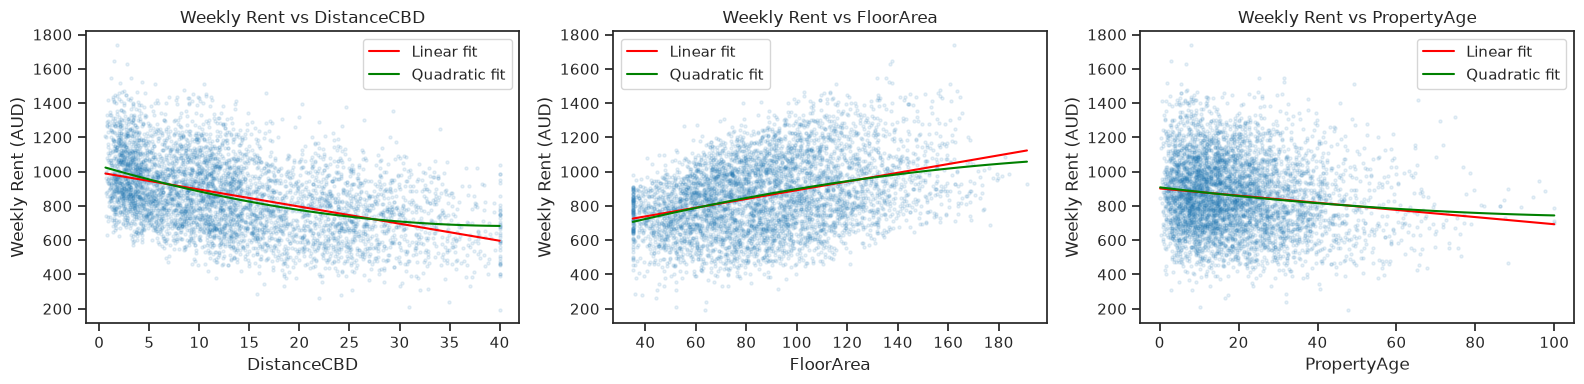

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# One row of three panels, one panel per continuous predictor
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

for i, var in enumerate(continuous):
    x = train[[var]].values                    # predictor as a 2-D array (sklearn needs 2-D input)
    y = train[response]                        # weekly rent
    x_points = np.linspace(x.min(), x.max(), 100).reshape(-1, 1) # evenly spaced values to draw the curves

    # Straight line: rent = b0 + b1*x
    lin_reg = LinearRegression()
    lin_reg.fit(x, y)

    # Quadratic curve: rent = b0 + b1*x + b2*x^2
    poly_transformer = PolynomialFeatures(2)       # will create columns [1, x, x^2]
    poly_x = poly_transformer.fit_transform(x)     # the new 3-column data
    poly_reg = LinearRegression()
    poly_reg.fit(poly_x, y)

    ax[i].scatter(x, y, alpha = 0.1, s = 5)
    ax[i].plot(x_points, lin_reg.predict(x_points), color = "red", label = "Linear fit")
    ax[i].plot(x_points, poly_reg.predict(poly_transformer.transform(x_points)), color = "green", label = "Quadratic fit")
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Weekly Rent (AUD)")
    ax[i].set_title("Weekly Rent vs " + var)
    ax[i].legend()

plt.tight_layout()
plt.show()

### 2.7 Weekly rent by `Bedrooms` and by the binary predictors

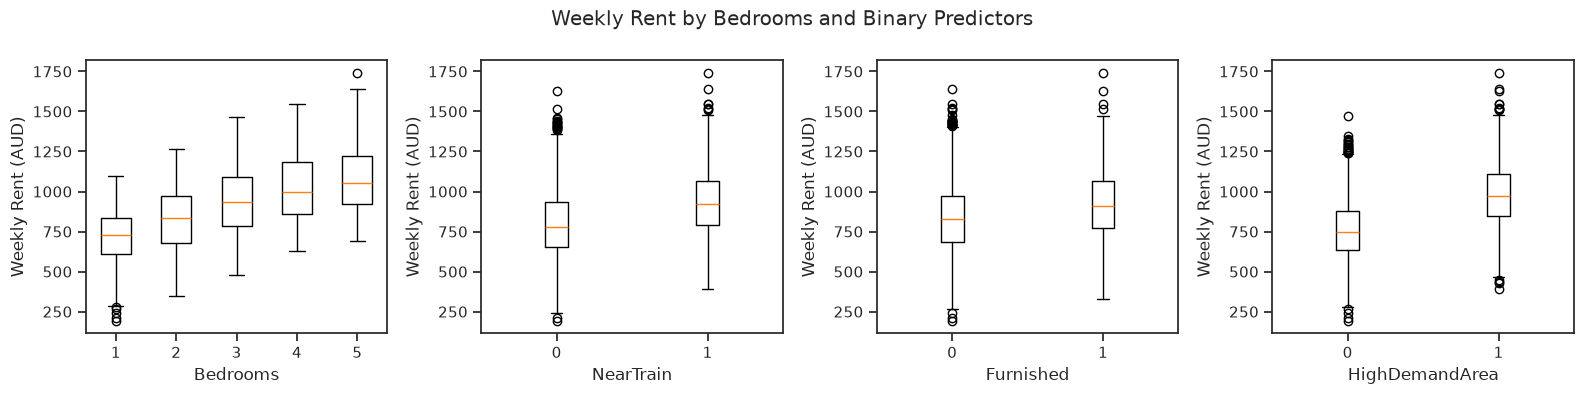

In [10]:
# NOTE: not from tutorial — reason: box plots are requested for this EDA; the tutorials compare groups with overlaid histograms (W1)
group_vars = ['Bedrooms'] + binary     # join two lists: ['Bedrooms', 'NearTrain', 'Furnished', 'HighDemandArea']

# One row of four panels, one per grouping variable
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

for i, var in enumerate(group_vars):
    levels = sorted(train[var].unique())     # the distinct values of this variable, e.g. [0, 1]

    # Collect the rents of each group into a list
    groups = []                              # start with an empty list
    for level in levels:
        rent_in_group = train.loc[train[var] == level, response]   # rents of properties in this group
        groups.append(rent_in_group)                               # add them to the list

    ax[i].boxplot(groups)                    # one box per group
    ax[i].set_xticklabels(levels)            # label each box with its group value (default would be 1, 2, ...)
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Weekly Rent (AUD)")

fig.suptitle("Weekly Rent by Bedrooms and Binary Predictors")   # title for the whole figure
plt.tight_layout()                           # adjust spacing so labels do not overlap
plt.show()

In [11]:
# For each grouping variable, show how many properties are in each group and their mean rent
for var in group_vars:
    # groupby(var): split the data into groups by the value of var (e.g. NearTrain = 0 and 1)
    # [response]: look at weekly rent only
    # agg(['count', 'mean']): for each group, count the properties and compute the mean rent
    # '\n': print a blank line between the tables
    print(train.groupby(var)[response].agg(['count', 'mean']).round(4), '\n')

          count       mean
Bedrooms                  
1          1213   717.9369
2          1741   823.7616
3          1264   938.8978
4           583  1020.8464
5           199  1087.7315 

           count      mean
NearTrain                 
0           2690  797.2066
1           2310  934.5973 

           count      mean
Furnished                 
0           3501  835.9160
1           1499  918.5214 

                count      mean
HighDemandArea                 
0                2719  759.2359
1                2281  981.6058 



**Summary.** Rent rises with bedrooms (718 to 1088 AUD) but by less for each extra bedroom. High-demand areas (+222 AUD),
train access (+137) and furnishing (+83) have higher rent (raw differences, not controlling for other predictors).

### 2.8 Correlations

Correlations rank predictors by their linear association with rent and reveal multicollinearity.

In [12]:
correlations = train.corr()
correlations.round(4)

,WeeklyRent,DistanceCBD,Bedrooms,FloorArea,PropertyAge,NearTrain,Furnished,HighDemandArea
WeeklyRent,1.0000,-0.4421,0.5062,0.3567,-0.1375,0.3180,0.1757,0.5142
DistanceCBD,-0.4421,1.0000,0.3319,0.5286,0.0163,-0.1780,-0.1300,-0.3727
Bedrooms,0.5062,0.3319,1.0000,0.8821,-0.0009,-0.0589,-0.1297,-0.1276
FloorArea,0.3567,0.5286,0.8821,1.0000,-0.0079,-0.0882,-0.1339,-0.1947
PropertyAge,-0.1375,0.0163,-0.0009,-0.0079,1.0000,0.0186,-0.0598,-0.0104
NearTrain,0.3180,-0.1780,-0.0589,-0.0882,0.0186,1.0000,0.0039,0.2385
Furnished,0.1757,-0.1300,-0.1297,-0.1339,-0.0598,0.0039,1.0000,0.0273
HighDemandArea,0.5142,-0.3727,-0.1276,-0.1947,-0.0104,0.2385,0.0273,1.0000


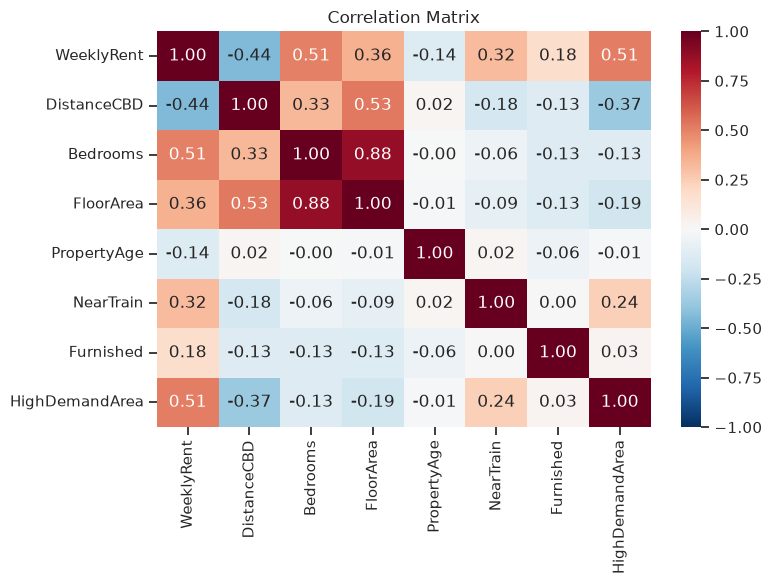

In [13]:
# NOTE: not from tutorial — reason: a heatmap displays the correlation table above more clearly (seaborn is used in W2)
fig = plt.figure(figsize=(8, 6))

sns.heatmap(correlations, annot = True, fmt = ".2f", cmap = "RdBu_r", vmin = -1, vmax = 1)
plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

Correlation of each predictor with rent, sorted (as in Tutorial 5):

In [14]:
# Correlation of each predictor with rent (the WeeklyRent column), without rent itself
rent_corr = correlations[response].drop(response)
# Sort from the largest to the smallest value
rent_corr = rent_corr.sort_values(ascending = False)
rent_corr.round(4)

HighDemandArea    0.5142
Bedrooms          0.5062
FloorArea         0.3567
NearTrain         0.3180
Furnished         0.1757
PropertyAge      -0.1375
DistanceCBD      -0.4421
Name: WeeklyRent, dtype: float64

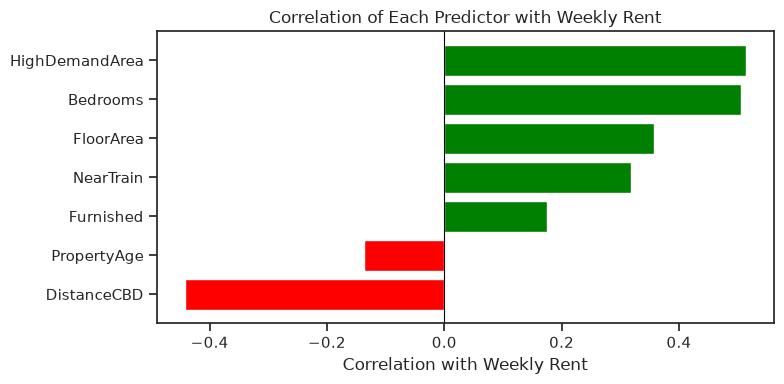

In [15]:
# NOTE: not from tutorial — reason: a bar chart shows the ranking of the correlations above more clearly
fig = plt.figure(figsize=(8, 4))

# One horizontal bar per predictor; green = positive, red = negative correlation
colors = ["green" if value > 0 else "red" for value in rent_corr]
plt.barh(rent_corr.index, rent_corr.values, color = colors)
plt.axvline(0, color = "black", linewidth = 0.8)   # vertical line at zero
plt.gca().invert_yaxis()                            # put the strongest positive correlation at the top
plt.xlabel("Correlation with Weekly Rent")
plt.title("Correlation of Each Predictor with Weekly Rent")
plt.tight_layout()

plt.show()

**Summary.** `HighDemandArea` and `Bedrooms` are most correlated with rent (0.51), then `DistanceCBD` (-0.44).
`Bedrooms` and `FloorArea` are highly correlated (0.88).

### 2.9 Interaction exploration

An interaction means the effect of one predictor depends on another (Lecture 2). For each pair, a separate line is
fitted in each group: non-parallel lines suggest an interaction.

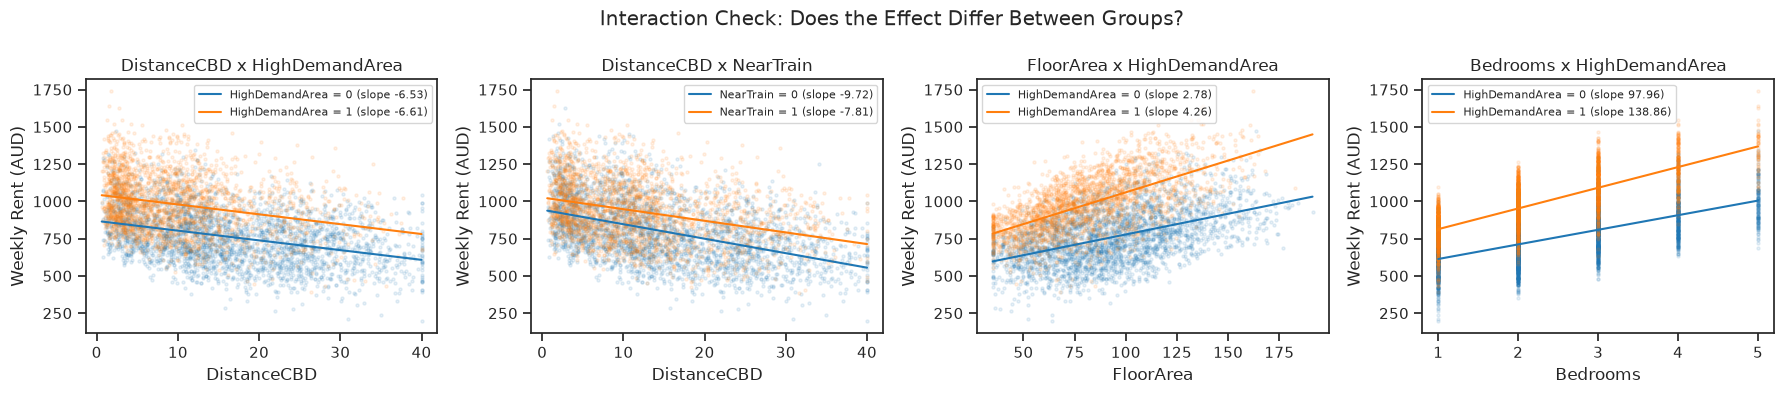

In [16]:
# Pairs to check: (predictor on the x-axis, binary variable used to split the data)
pairs = [('DistanceCBD', 'HighDemandArea'), ('DistanceCBD', 'NearTrain'),
         ('FloorArea', 'HighDemandArea'), ('Bedrooms', 'HighDemandArea')]

fig, ax = plt.subplots(1, 4, figsize=(18, 4))     # one row of four panels

for i, (var, group) in enumerate(pairs):
    # Two groups: level 0 in blue, level 1 in orange (zip pairs each level with a colour)
    for level, color in zip([0, 1], ["#1F77B4", "#FF7F0E"]):
        subset = train[train[group] == level]                      # properties in this group only
        # Simple OLS within the group: rent = b0 + b1 * var
        x_with_intercept = sm.add_constant(subset[[var]], prepend=True)
        est = sm.OLS(subset[response], x_with_intercept).fit()
        x_points = np.linspace(train[var].min(), train[var].max(), 100)   # points to draw the line

        ax[i].scatter(subset[var], subset[response], alpha = 0.1, s = 5, color = color)
        # Fitted line b0 + b1 * x; the legend shows the slope b1 of this group
        ax[i].plot(x_points, est.params.iloc[0] + est.params.iloc[1] * x_points, color = color,
                   label = "{} = {} (slope {:.2f})".format(group, level, est.params.iloc[1]))
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Weekly Rent (AUD)")
    ax[i].set_title(var + " x " + group)           # which pair this panel checks
    ax[i].legend(fontsize = 8)                     # small legend so it does not cover the points

# Different slopes (non-parallel lines) suggest an interaction
fig.suptitle("Interaction Check: Does the Effect Differ Between Groups?")
plt.tight_layout()
plt.show()

**Summary.** The lines for `Bedrooms` (139 vs 98 AUD per bedroom) and `FloorArea` (4.26 vs 2.78 AUD per m²) are not
parallel, suggesting interactions with `HighDemandArea`. The distance lines are almost parallel. These slopes do not
control for other predictors, so interaction terms are tested in Section 3.

### 2.10 Baseline OLS model and outlier check

In [17]:
# Baseline OLS: rent on the seven predictors (linear terms only), as in Tutorial 7
x_with_intercept = sm.add_constant(train[predictors], prepend=True)   # add a column of ones for the intercept
ols = sm.OLS(train[response], x_with_intercept)                       # set up the model: y = rent, X = predictors
est = ols.fit()                                                       # estimate the coefficients by least squares
print(est.summary())                                                  # coefficients, p-values, R-squared, AIC, BIC

                            OLS Regression Results                            
Dep. Variable:             WeeklyRent   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     9345.
Date:                Sun, 27 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:46:04   Log-Likelihood:                -27341.
No. Observations:                5000   AIC:                         5.470e+04
Df Residuals:                    4992   BIC:                         5.475e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            481.9479      3.335    144.

**Result.** R² = 0.929 and all seven predictors are significant (p < 0.001).

In [18]:
# Residual = actual rent - fitted rent, one value per property
residuals = est.resid

**Outlier check.** Standardised residual = residual / estimated error standard deviation.
Under normal errors about 0.27% of observations should exceed ±3.

In [19]:
from scipy import stats

# Estimated standard deviation of the errors (square root of the residual mean squared error)
sigma_hat = np.sqrt(est.mse_resid)
# Standardised residual = residual / sigma_hat
std_resid = residuals / sigma_hat

# Flag observations more than 3 standard deviations away from their fitted value
outliers = np.abs(std_resid) > 3
# Number expected by chance if the errors are normal: n x P(|Z| > 3)
expected = len(train) * 2 * (1 - stats.norm.cdf(3))

print('Observations with |standardised residual| > 3: {}'.format(outliers.sum()))
print('Expected by chance under normal errors:        {0:.4f}'.format(expected))
print('Largest |standardised residual|:              {0:.4f}'.format(np.abs(std_resid).max()))

Observations with |standardised residual| > 3: 17
Expected by chance under normal errors:        13.4990
Largest |standardised residual|:              4.2356


In [20]:
# Show the flagged observations, sorted by their standardised residual
outlier_rows = train[outliers].copy()
outlier_rows['std_resid'] = std_resid[outliers]
outlier_rows.sort_values('std_resid').round(4)

,WeeklyRent,DistanceCBD,Bedrooms,FloorArea,PropertyAge,NearTrain,Furnished,HighDemandArea,std_resid
56,779.24,30.82,5,174.3,15.6,0,0,0,-3.3569
2503,606.96,9.19,1,47.5,13.9,1,0,1,-3.3540
3018,683.11,11.67,1,53.1,14.2,1,1,1,-3.2787
2046,1054.19,14.51,5,161.1,14.7,1,0,0,-3.1635
908,1023.68,8.06,5,155.4,29.2,0,0,0,-3.1113
48,847.13,22.18,5,153.3,17.6,0,0,0,-3.0711
1300,689.50,33.42,5,176.7,63.3,0,0,0,-3.0137
4635,1273.12,2.16,3,60.6,19.4,0,1,1,3.0014
3653,926.79,34.22,3,116.5,20.1,1,1,0,3.1136
1332,598.04,35.68,1,90.0,6.5,1,0,0,3.1598


**Result.** 17 observations exceed ±3 (13.5 expected by chance; largest 4.24). They are mainly distant or five-bedroom
properties that the linear model fits poorly, not data errors, so all observations are kept.

### 2.11 Summary of EDA findings

- No missing values or duplicates; test covariates match the training covariates.
- No data errors; the 17 large residuals are kept.
- `WeeklyRent` is roughly symmetric (skewness 0.27), so it is not transformed.
- Rent is non-linear in `DistanceCBD` and `FloorArea`.
- `Bedrooms` and `FloorArea` are highly correlated (0.88).
- `Bedrooms` and `FloorArea` may interact with `HighDemandArea`.
- The linear OLS already has R² = 0.929.

## 3. Modelling and model selection

Each model is fitted and then evaluated with **10-fold cross-validation** (CV) on the same folds (Tutorials 5–6).
The final model has the smallest CV MSE; if models are within one standard error, the simpler one is chosen.
Ridge, lasso, elastic net and KNN standardise the predictors inside each fold (`Pipeline`) to avoid data leakage.

### 3.1 Cross-validation set-up

The same 10 folds (`kf`) are used for every model, so the CV errors can be compared fairly (Tutorial 6).
`cv_mse(model, X)` runs the 10-fold CV for one model and returns the CV MSE and its standard error (SE).

In [21]:
from sklearn.model_selection import KFold, cross_val_score

y = train[response]

# 10-fold CV with shuffling; random_state fixes the folds, so every model uses the same folds
kf = KFold(10, shuffle=True, random_state=1)

def cv_mse(model, X):
    # fit on 9 folds (4500 rows), predict the held-out fold (500 rows), 10 times
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    fold_mse = -scores                                      # scikit-learn returns negative MSE, so change the sign
    mean_mse = np.mean(fold_mse)                            # CV MSE = average of the 10 fold MSEs
    se = np.std(fold_mse, ddof=1) / np.sqrt(len(fold_mse))  # standard error = sample std of fold MSEs / sqrt(10)
    return mean_mse, se                                     # returns two numbers

results = []   # one dictionary per model, turned into a table at the end (as in Tutorial 6)

### 3.2 Baseline models: M0 and M1

- **M0:** predicts the average rent for every property.
- **M1:** OLS with the seven original predictors.

In [22]:
# M0: predict the average rent of the training folds (manual loop over the same folds)
fold_mse = []
for train_index, valid_index in kf.split(train):
    prediction = y.iloc[train_index].mean()                              # mean rent of the training folds
    fold_mse.append(np.mean((y.iloc[valid_index] - prediction) ** 2))    # MSE on the validation fold

m0_mse = np.mean(fold_mse)
m0_se = np.std(fold_mse, ddof=1) / np.sqrt(len(fold_mse))
results.append({'Model': 'M0: Null model', 'CV MSE': m0_mse, 'SE': m0_se})
print('M0 prediction on all training data: {0:.4f} AUD'.format(y.mean()))
print('M0 CV MSE: {0:.4f} (SE {1:.4f})'.format(m0_mse, m0_se))

M0 prediction on all training data: 860.6811 AUD
M0 CV MSE: 46409.4061 (SE 842.9485)


In [23]:
from sklearn.linear_model import LinearRegression

# M1: OLS with the seven original predictors
X_m1 = train[predictors]          # 5000 x 7 table of predictors (y = WeeklyRent, defined in 3.1)

# Create the linear regression object (empty model, nothing learned yet)
lin_reg = LinearRegression()

# Estimate the coefficients by least squares on all 5000 training rows (only to look at them)
lin_reg.fit(X_m1, y)

# Print the fitted equation: intercept and one slope per predictor
print('Intercept: {0:.4f}'.format(lin_reg.intercept_))
for name, coef in zip(predictors, lin_reg.coef_):        # pair each predictor name with its coefficient
    print('{0}: {1:.4f}'.format(name, coef))

Intercept: 481.9479
DistanceCBD: -13.6208
Bedrooms: 83.0277
FloorArea: 2.9902
PropertyAge: -1.7023
NearTrain: 79.6334
Furnished: 89.3712
HighDemandArea: 161.6766


The CV MSE of M1 is computed with `cv_mse` on the same folds as M0.

In [24]:
# 10-fold CV of M1 (cv_mse is defined in 3.1)
m1_mse, m1_se = cv_mse(lin_reg, X_m1)
results.append({'Model': 'M1: OLS, 7 linear terms', 'CV MSE': m1_mse, 'SE': m1_se})   # store for the comparison table
print('M1 CV MSE: {0:.4f} (SE {1:.4f})'.format(m1_mse, m1_se))

M1 CV MSE: 3302.3821 (SE 29.6067)


**Result.** M1 reduces the CV MSE from about 46,400 (M0) to about 3,300.

### 3.3 M2: best subset selection

Are all seven predictors needed? Following Lectures 4–5, all 127 non-empty subsets of the seven predictors are fitted by OLS
(128 including the null model M0). Within each size, the subset with the smallest RSS is kept. The best models of different sizes
are then compared by 10-fold CV, because RSS always decreases as predictors are added.

In [25]:
# NOTE: not from tutorial — reason: itertools.combinations lists all subsets of a given size for best subset selection (Lectures 4-5)
import itertools

best_subsets = []                                         # best model of each size
for k in range(1, len(predictors) + 1):                   # k = 1, 2, ..., 7 predictors
    best_rss = np.inf                                     # reset for each size k: any real RSS beats infinity
    for subset in itertools.combinations(predictors, k):  # try every model with exactly k predictors (e.g. 21 when k = 2)
        x_with_intercept = sm.add_constant(train[list(subset)], prepend=True)   # these k columns + intercept (Tutorial 7)
        est = sm.OLS(y, x_with_intercept).fit()                                 # fit OLS by least squares
        if est.ssr < best_rss:                            # ssr = residual sum of squares (RSS); smaller than the best so far?
            best_rss = est.ssr                            # keep the new best RSS
            best_subset = list(subset)                    # and its predictors

    mse, se = cv_mse(LinearRegression(), train[best_subset])   # CV MSE of the best model of this size
    best_subsets.append({'Size': k, 'Predictors': best_subset, 'RSS': best_rss, 'CV MSE': mse, 'SE': se})

best_subsets = pd.DataFrame(best_subsets).set_index('Size')   # one row per model size
best_subsets.round(4)

,Predictors,RSS,CV MSE,SE
Size,,,,
1,[HighDemandArea],1.706329e+08,34146.8768,627.9167
2,"[DistanceCBD, FloorArea]",7.442294e+07,14900.7981,211.7488
3,"[DistanceCBD, FloorArea, HighDemandArea]",4.188526e+07,8388.2431,107.5607
4,"[DistanceCBD, Bedrooms, Furnished, HighDemandA...",3.340712e+07,6695.8734,98.2287
5,"[DistanceCBD, Bedrooms, NearTrain, Furnished, ...",2.608617e+07,5233.3094,107.4317
6,"[DistanceCBD, Bedrooms, FloorArea, NearTrain, ...",1.934817e+07,3882.9493,51.8272
7,"[DistanceCBD, Bedrooms, FloorArea, PropertyAge...",1.644736e+07,3302.3821,29.6067


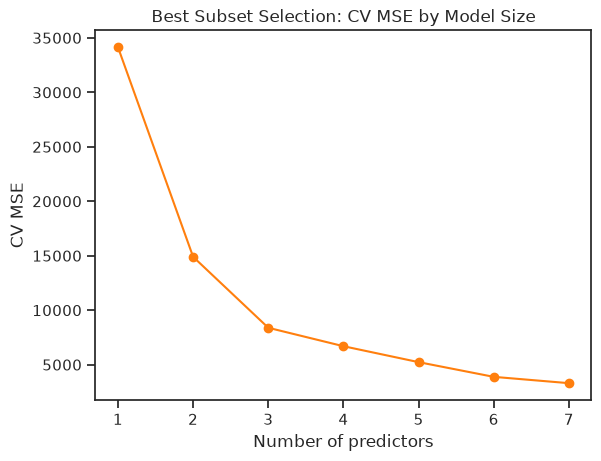

Best size: 7 predictors
Predictors: ['DistanceCBD', 'Bedrooms', 'FloorArea', 'PropertyAge', 'NearTrain', 'Furnished', 'HighDemandArea']
M2 CV MSE: 3302.3821 (SE 29.6067)


In [26]:
# Plot CV MSE against model size: RSS always falls with more predictors, CV MSE does not have to
fig = plt.figure()
plt.plot(best_subsets.index, best_subsets['CV MSE'], marker = 'o', color = '#FF7F0E')
plt.xlabel('Number of predictors')
plt.ylabel('CV MSE')
plt.title('Best Subset Selection: CV MSE by Model Size')
plt.show()

best_size = best_subsets['CV MSE'].idxmin()                # size with the smallest CV MSE
m2_mse = best_subsets.loc[best_size, 'CV MSE']             # CV MSE of M2
m2_se = best_subsets.loc[best_size, 'SE']                  # its standard error
results.append({'Model': 'M2: Best subset ({} predictors)'.format(best_size), 'CV MSE': m2_mse, 'SE': m2_se})   # store for the comparison table
print('Best size: {} predictors'.format(best_size))
print('Predictors:', best_subsets.loc[best_size, 'Predictors'])
print('M2 CV MSE: {0:.4f} (SE {1:.4f})'.format(m2_mse, m2_se))

**Result.** CV MSE falls at every size, so the best subset contains all seven predictors and M2 equals M1. The best single predictor
(`HighDemandArea`) is not in the best two-predictor model (`DistanceCBD`, `FloorArea`), which shows why stepwise selection may miss
the best subset. Linear terms alone cannot capture the curvature found in the EDA.

### 3.4 Expanded features

`make_features(df)` adds 4 squared terms and 21 pairwise interactions to the seven predictors (32 columns).
The same function is applied to the test data later.

In [27]:
def make_features(df):
    # Start from the seven original predictors
    features = df[predictors].copy()

    # Squared terms (not for 0/1 variables, since 0^2 = 0 and 1^2 = 1)
    for var in ['DistanceCBD', 'FloorArea', 'Bedrooms', 'PropertyAge']:
        features[var + '_SQ'] = features[var] ** 2

    # All pairwise interactions: product of two predictors
    for j in range(len(predictors)):
        for k in range(j + 1, len(predictors)):     # each pair once, never a predictor with itself
            var1 = predictors[j]
            var2 = predictors[k]
            features[var1 + '_x_' + var2] = features[var1] * features[var2]

    return features

X_all = make_features(train)                                        # 32 columns
extra_terms = [c for c in X_all.columns if c not in predictors]     # the 25 squared and interaction terms
print('Number of columns: {}'.format(X_all.shape[1]))

Number of columns: 32


### 3.5 M3: EDA-driven OLS

The seven predictors plus the terms suggested by the EDA:

| Term | EDA evidence |
|---|---|
| `DistanceCBD_SQ`, `FloorArea_SQ` | curvature (Section 2.6) |
| `Bedrooms_SQ` | smaller increase per extra bedroom (Section 2.7) |
| `Bedrooms_x_HighDemandArea`, `FloorArea_x_HighDemandArea`, `DistanceCBD_x_NearTrain` | different slopes (Section 2.9) |

In [28]:
eda_terms = ['DistanceCBD_SQ', 'FloorArea_SQ', 'Bedrooms_SQ',
             'Bedrooms_x_HighDemandArea', 'FloorArea_x_HighDemandArea', 'DistanceCBD_x_NearTrain']

# Fit on all training data to look at the coefficients and p-values of the added terms (as in Tutorial 7)
x_with_intercept = sm.add_constant(X_all[predictors + eda_terms], prepend=True)
m3 = sm.OLS(y, x_with_intercept).fit()
print(pd.DataFrame({'coef': m3.params[eda_terms], 'p-value': m3.pvalues[eda_terms]}).round(4))

# CV MSE of the EDA-driven model
mse, se = cv_mse(LinearRegression(), X_all[predictors + eda_terms])
results.append({'Model': 'M3: EDA-driven OLS, 6 extra terms', 'CV MSE': mse, 'SE': se})
print('\nM3 CV MSE: {0:.4f} (SE {1:.4f})'.format(mse, se))

                               coef  p-value
DistanceCBD_SQ               0.2951   0.0000
FloorArea_SQ                -0.0124   0.0000
Bedrooms_SQ                 -0.3575   0.6078
Bedrooms_x_HighDemandArea   32.7640   0.0000
FloorArea_x_HighDemandArea  -0.0662   0.4913
DistanceCBD_x_NearTrain      2.7860   0.0000

M3 CV MSE: 2075.4951 (SE 27.7922)


**Result.** CV MSE falls from 3302 (M1) to about 2075, so the EDA terms help. `Bedrooms_SQ` and `FloorArea_x_HighDemandArea` are not
significant, because `Bedrooms` and `FloorArea` are highly correlated; stepwise selection is used to choose terms systematically.

### 3.6 M4: forward stepwise selection

Starting from the seven predictors, add the squared or interaction term with the smallest RSS at each step (Lectures 4–5).
The models with the smallest AIC and BIC on this path are evaluated by CV. AIC and BIC are computed as in Tutorial 6:
$AIC = n\log(\hat{\sigma}^2) + 2d$ and $BIC = n\log(\hat{\sigma}^2) + \log(n)d$, where $\hat{\sigma}^2 = RSS/n$ and $d$ is the number of
parameters (intercept, slopes and error variance).

In [29]:
# NOTE: not from tutorial — reason: Tutorial 7 removes predictors by hand; this loop automates forward stepwise selection (Lectures 4-5)
def fit_ols(terms):
    # OLS with the seven main effects plus the given extra terms (statsmodels, as in Tutorial 7)
    x_with_intercept = sm.add_constant(X_all[predictors + terms], prepend=True)
    return sm.OLS(y, x_with_intercept).fit()

from sklearn.metrics import mean_squared_error

n = len(y)                                 # number of observations (5000)

def aic_bic(terms):
    # AIC and BIC as in Tutorial 6: n*log(sigma2_hat) + penalty * number_of_parameters
    X = X_all[predictors + terms]
    lin_reg = LinearRegression()                              # Create the linear regression object
    lin_reg.fit(X, y)                                         # Estimate coefficients
    y_pred = lin_reg.predict(X)                               # Calculate predictions
    sigma2_hat = mean_squared_error(y, y_pred)                # sigma2_hat = RSS / n
    number_of_parameters = len(predictors) + len(terms) + 2   # intercept + slopes + error variance
    aic_value = n * np.log(sigma2_hat) + 2 * number_of_parameters
    bic_value = n * np.log(sigma2_hat) + np.log(n) * number_of_parameters
    return aic_value, bic_value

forward_path = []                          # one row per step of the path
current = []                               # extra terms in the current model (start: none = M1)
remaining = list(extra_terms)              # the 25 candidate terms not yet added
aic_value, bic_value = aic_bic(current)    # step 0: the seven main effects only
forward_path.append({'Extra terms': 0, 'Terms': list(current), 'AIC': aic_value, 'BIC': bic_value})

while len(remaining) > 0:                  # repeat until every candidate term has been added
    best_rss = np.inf                      # reset for each step: any real RSS beats infinity
    for term in remaining:                 # try adding each remaining term, one at a time
        est = fit_ols(current + [term])
        if est.ssr < best_rss:             # ssr = RSS; keep the term that lowers RSS the most
            best_rss = est.ssr
            best_term = term
    current.append(best_term)              # add the winning term to the model
    remaining.remove(best_term)            # and take it out of the candidate list
    aic_value, bic_value = aic_bic(current)   # AIC and BIC of the new model
    forward_path.append({'Extra terms': len(current), 'Terms': list(current), 'AIC': aic_value, 'BIC': bic_value})

forward_path = pd.DataFrame(forward_path).set_index('Extra terms')

In [30]:
# Pick the models with the smallest AIC and BIC on the path, then evaluate them by CV
for criterion in ['AIC', 'BIC']:
    terms = forward_path.loc[forward_path[criterion].idxmin(), 'Terms']   # terms of the step with the smallest AIC (or BIC)
    mse, se = cv_mse(LinearRegression(), X_all[predictors + terms])       # 10-fold CV of that model
    results.append({'Model': 'M4: Forward stepwise ({}), {} extra terms'.format(criterion, len(terms)),
                    'CV MSE': mse, 'SE': se})                               # store for the comparison table
    print('Forward ({}): {} extra terms {}'.format(criterion, len(terms), terms))
    print('   CV MSE {:.4f} (SE {:.4f})'.format(mse, se))

Forward (AIC): 7 extra terms ['DistanceCBD_SQ', 'Bedrooms_x_HighDemandArea', 'FloorArea_SQ', 'DistanceCBD_x_NearTrain', 'Bedrooms_x_Furnished', 'PropertyAge_SQ', 'Furnished_x_HighDemandArea']
   CV MSE 2005.8861 (SE 26.4687)
Forward (BIC): 6 extra terms ['DistanceCBD_SQ', 'Bedrooms_x_HighDemandArea', 'FloorArea_SQ', 'DistanceCBD_x_NearTrain', 'Bedrooms_x_Furnished', 'PropertyAge_SQ']
   CV MSE 2005.6203 (SE 27.4624)


### 3.7 M5: backward stepwise selection

Starting from all 32 columns, remove the squared or interaction term whose removal gives the smallest RSS at each step.
The models with the smallest AIC and BIC are evaluated by CV. The seven predictors are always kept.

In [31]:
# NOTE: not from tutorial — reason: automates the backward elimination done by hand in Tutorial 7 (Lectures 4-5)
backward_path = []                    # one row per step of the path
current = list(extra_terms)           # start with all 25 extra terms (full model, 32 columns)
aic_value, bic_value = aic_bic(current)
backward_path.append({'Extra terms': len(current), 'Terms': list(current), 'AIC': aic_value, 'BIC': bic_value})

while len(current) > 0:               # repeat until every extra term has been removed
    best_rss = np.inf                 # reset for each step
    for term in current:              # try removing each term, one at a time
        reduced = [t for t in current if t != term]   # current terms without this one
        est = fit_ols(reduced)
        if est.ssr < best_rss:        # removal that keeps RSS smallest = least useful term
            best_rss = est.ssr
            worst_term = term
    current.remove(worst_term)        # remove the least useful term
    aic_value, bic_value = aic_bic(current)   # AIC and BIC of the smaller model (Tutorial 6 formula)
    backward_path.append({'Extra terms': len(current), 'Terms': list(current), 'AIC': aic_value, 'BIC': bic_value})

backward_path = pd.DataFrame(backward_path).set_index('Extra terms')

for criterion in ['AIC', 'BIC']:
    terms = backward_path.loc[backward_path[criterion].idxmin(), 'Terms']
    mse, se = cv_mse(LinearRegression(), X_all[predictors + terms])
    results.append({'Model': 'M5: Backward stepwise ({}), {} extra terms'.format(criterion, len(terms)),
                    'CV MSE': mse, 'SE': se})
    print('Backward ({}): {} extra terms {}'.format(criterion, len(terms), terms))
    print('   CV MSE {:.4f} (SE {:.4f})'.format(mse, se))

Backward (AIC): 7 extra terms ['DistanceCBD_SQ', 'FloorArea_SQ', 'PropertyAge_SQ', 'DistanceCBD_x_NearTrain', 'Bedrooms_x_Furnished', 'Bedrooms_x_HighDemandArea', 'Furnished_x_HighDemandArea']
   CV MSE 2005.8861 (SE 26.4687)
Backward (BIC): 6 extra terms ['DistanceCBD_SQ', 'FloorArea_SQ', 'PropertyAge_SQ', 'DistanceCBD_x_NearTrain', 'Bedrooms_x_Furnished', 'Bedrooms_x_HighDemandArea']
   CV MSE 2005.6203 (SE 27.4624)


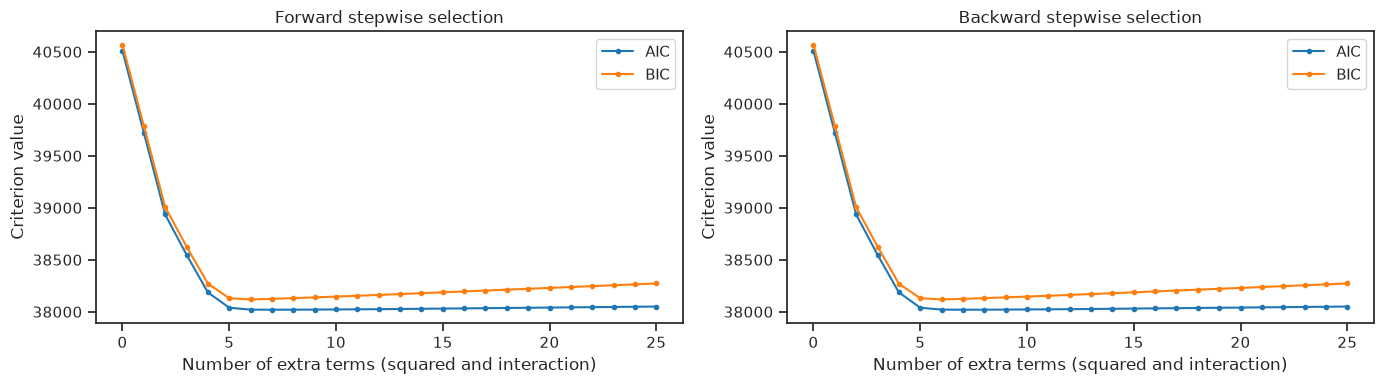

In [32]:
# AIC and BIC along the forward and backward paths
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for i, (path, name) in enumerate([(forward_path, 'Forward'), (backward_path, 'Backward')]):
    ax[i].plot(path.index, path['AIC'], marker = 'o', markersize = 3, label = 'AIC')
    ax[i].plot(path.index, path['BIC'], marker = 'o', markersize = 3, label = 'BIC')
    ax[i].set_xlabel('Number of extra terms (squared and interaction)')
    ax[i].set_ylabel('Criterion value')
    ax[i].set_title(name + ' stepwise selection')
    ax[i].legend()
plt.tight_layout()
plt.show()

**Result.** Forward and backward selection choose the same terms. BIC keeps six: `DistanceCBD_SQ`, `FloorArea_SQ`,
`PropertyAge_SQ`, `Bedrooms_x_HighDemandArea`, `Bedrooms_x_Furnished` and `DistanceCBD_x_NearTrain`.

### 3.8 M6: ridge, lasso and elastic net

All 32 standardised columns with a penalty λ (Lectures 6–7), chosen by a CV loop over a grid as in Tutorial 5.

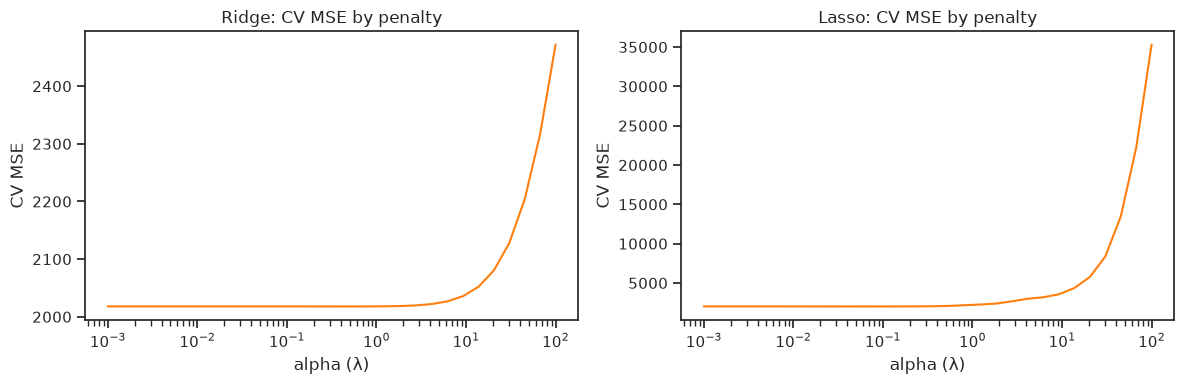

M6: Ridge (alpha = 0.3857): CV MSE 2017.8831 (SE 27.2966)


M6: Lasso (alpha = 0.0788): CV MSE 2012.2895 (SE 25.5644)


In [33]:
# NOTE: not from tutorial — reason: make_pipeline puts the StandardScaler inside each CV fold, so the validation fold is
#       never used to compute the mean and standard deviation (decision at Checkpoint 0); Ridge and ElasticNet are in
#       Lectures 6-7 and are used in the same way as Lasso in Tutorial 7
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet

alphas = np.logspace(-3, 2, 30)          # grid of penalty values from 0.001 to 100

ridge_cv = []
lasso_cv = []
for alpha in alphas:
    mse, se = cv_mse(make_pipeline(StandardScaler(), Ridge(alpha = alpha)), X_all)
    ridge_cv.append(mse)
    mse, se = cv_mse(make_pipeline(StandardScaler(), Lasso(alpha = alpha, max_iter = 100000)), X_all)
    lasso_cv.append(mse)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, (cv_errors, name) in enumerate([(ridge_cv, 'Ridge'), (lasso_cv, 'Lasso')]):
    ax[i].plot(alphas, cv_errors, color = '#FF7F0E')
    ax[i].set_xscale('log')                              # the λ grid is spread on a log scale
    ax[i].set_xlabel('alpha (λ)')
    ax[i].set_ylabel('CV MSE')
    ax[i].set_title(name + ': CV MSE by penalty')
plt.tight_layout()
plt.show()

best_ridge_alpha = alphas[np.argmin(ridge_cv)]
best_lasso_alpha = alphas[np.argmin(lasso_cv)]
for name, model in [('M6: Ridge (alpha = {:.4f})'.format(best_ridge_alpha),
                     make_pipeline(StandardScaler(), Ridge(alpha = best_ridge_alpha))),
                    ('M6: Lasso (alpha = {:.4f})'.format(best_lasso_alpha),
                     make_pipeline(StandardScaler(), Lasso(alpha = best_lasso_alpha, max_iter = 100000)))]:
    mse, se = cv_mse(model, X_all)
    results.append({'Model': name, 'CV MSE': mse, 'SE': se})
    print('{}: CV MSE {:.4f} (SE {:.4f})'.format(name, mse, se))

In [34]:
# Elastic net: search over the mixing parameter and λ
best_enet_mse = np.inf
for l1_ratio in [0.2, 0.5, 0.8]:
    for alpha in alphas:
        model = make_pipeline(StandardScaler(), ElasticNet(alpha = alpha, l1_ratio = l1_ratio, max_iter = 100000))
        mse, se = cv_mse(model, X_all)
        if mse < best_enet_mse:                          # keep the best combination so far
            best_enet_mse, best_enet_se = mse, se
            best_enet = (alpha, l1_ratio)

results.append({'Model': 'M6: Elastic net (alpha = {:.4f}, l1_ratio = {})'.format(best_enet[0], best_enet[1]),
                'CV MSE': best_enet_mse, 'SE': best_enet_se})
print('Elastic net: alpha = {:.4f}, l1_ratio = {}, CV MSE {:.4f} (SE {:.4f})'.format(
    best_enet[0], best_enet[1], best_enet_mse, best_enet_se))

Elastic net: alpha = 0.0010, l1_ratio = 0.8, CV MSE 2017.8816 (SE 26.9696)


**Result.** Lasso is slightly better than ridge; the elastic net chooses almost no penalty. None beats the stepwise models.

### 3.9 M7: K-nearest neighbours

KNN on the seven standardised predictors; k is chosen by CV (Tutorial 5).

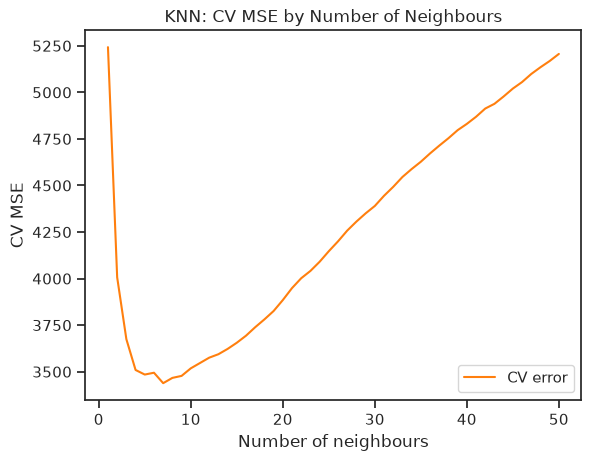

Best k = 7, CV MSE 3438.6270 (SE 69.4793)


In [35]:
from sklearn.neighbors import KNeighborsRegressor

neighbours = np.arange(1, 51)
knn_cv = []
for k in neighbours:
    knn = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors = k))
    mse, se = cv_mse(knn, train[predictors])
    knn_cv.append(mse)

fig, ax = plt.subplots()
ax.plot(neighbours, knn_cv, color='#FF7F0E', label='CV error')
ax.set_xlabel('Number of neighbours')
ax.set_ylabel('CV MSE')
ax.set_title('KNN: CV MSE by Number of Neighbours')
plt.legend()
plt.show()

best_k = neighbours[np.argmin(knn_cv)]
mse, se = cv_mse(make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors = best_k)), train[predictors])
results.append({'Model': 'M7: KNN (k = {})'.format(best_k), 'CV MSE': mse, 'SE': se})
print('Best k = {}, CV MSE {:.4f} (SE {:.4f})'.format(best_k, mse, se))

### 3.10 Model comparison

In [36]:
comparison_table = pd.DataFrame(results).set_index('Model').sort_values('CV MSE')
comparison_table.round(4)

,CV MSE,SE
Model,,
"M5: Backward stepwise (BIC), 6 extra terms",2005.6203,27.4624
"M4: Forward stepwise (BIC), 6 extra terms",2005.6203,27.4624
"M4: Forward stepwise (AIC), 7 extra terms",2005.8861,26.4687
"M5: Backward stepwise (AIC), 7 extra terms",2005.8861,26.4687
M6: Lasso (alpha = 0.0788),2012.2895,25.5644
"M6: Elastic net (alpha = 0.0010, l1_ratio = 0.8)",2017.8816,26.9696
M6: Ridge (alpha = 0.3857),2017.8831,27.2966
"M3: EDA-driven OLS, 6 extra terms",2075.4951,27.7922
"M1: OLS, 7 linear terms",3302.3821,29.6067


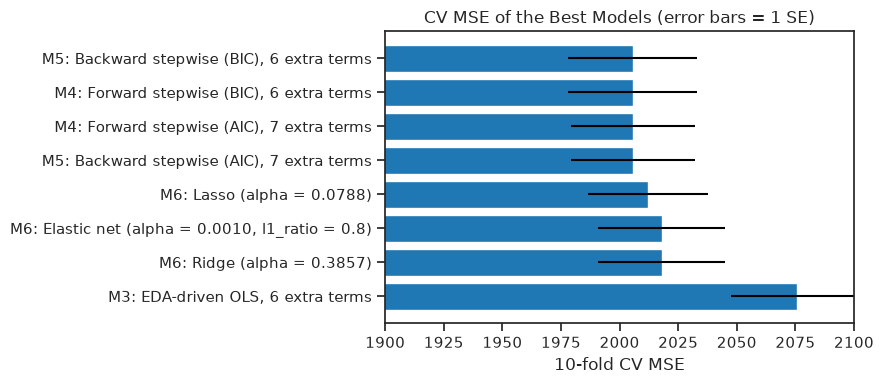

In [37]:
# Models close to the best one (M0, M1, the best subset and KNN have much larger errors)
close = comparison_table[comparison_table['CV MSE'] < 2500]

fig = plt.figure(figsize=(9, 4))
plt.barh(close.index, close['CV MSE'], xerr = close['SE'], color = '#1F77B4')   # error bars = 1 SE
plt.gca().invert_yaxis()                                                         # best model at the top
plt.xlim(1900, 2100)
plt.xlabel('10-fold CV MSE')
plt.title('CV MSE of the Best Models (error bars = 1 SE)')
plt.tight_layout()
plt.show()

**Result.** Forward and backward stepwise (BIC) have the lowest CV MSE (2005.62), and the other models close to them are
within one standard error. The stepwise (BIC) model is recommended: it is the simplest (6 extra terms) and easy to interpret.